In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error


In [ ]:
data=pd.read_csv(r"position_salaries.csv")
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [225]:
data.tail()

,Position,Level,Salary
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [226]:
data.columns

Index(['Position', 'Level', 'Salary'], dtype='str')

In [227]:
data.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [228]:
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [229]:
data.duplicated().sum()

np.int64(0)

In [230]:
data.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


Text(0.5, 1.0, 'Line plot of Level vs Salary')

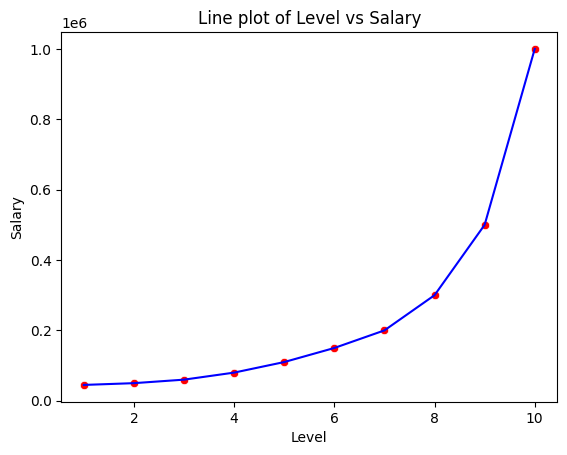

In [252]:
sns.lineplot(data=data,x="Level",y="Salary",color="blue")
sns.scatterplot(data=data,x="Level",y="Salary",color="red")
plt.title("Line plot of Level vs Salary")

In [232]:

x=data[["Level"]]
y=data["Salary"]


In [233]:
x.shape

(10, 1)

In [234]:
y.shape

(10,)

In [235]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
model=make_pipeline(PolynomialFeatures(degree=6,include_bias=False),Ridge(alpha=0.1))
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
y_pred

array([520247.48776822,  48679.83161153, 146978.82373405])

In [236]:

pd.DataFrame({ "r2_score": [r2_score(y_test,y_pred)], "Mean Absolute Error": [mean_absolute_error(y_test,y_pred)], "Root Mean Squared Error": [np.sqrt(mean_squared_error(y_test,y_pred))] })

,r2_score,Mean Absolute Error,Root Mean Squared Error
0,0.996231,8196.277474,11843.860738


Text(0.5, 0, 'Employee Experience Level')

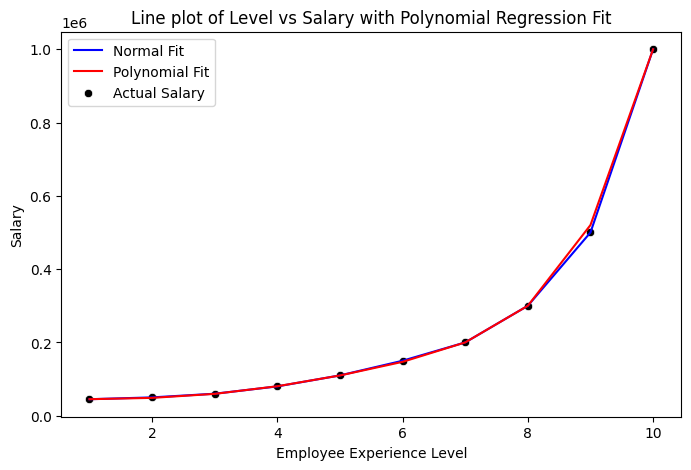

In [251]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=data,x="Level",y="Salary",color="blue",label="Normal Fit")
sns.lineplot(data=data,x="Level",y=model.predict(x),color="red",label="Polynomial Fit")
sns.scatterplot(data=data,x="Level",y="Salary",color="black",label="Actual Salary")
plt.title("Line plot of Level vs Salary with Polynomial Regression Fit")
plt.xlabel("Employee Experience Level")

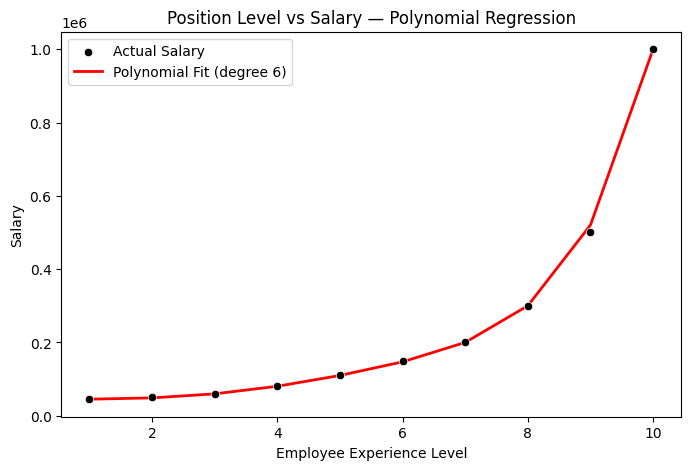

In [249]:


plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Level", y="Salary", color="black", zorder=5, label="Actual Salary")
plt.plot(data["Level"], model.predict(x), color="red", linewidth=2, label="Polynomial Fit (degree 6)")
plt.title("Position Level vs Salary — Polynomial Regression")
plt.xlabel("Employee Experience Level")
plt.ylabel("Salary")
plt.legend()

plt.show()